# Практичне заняття №6
## Гібридна система вибору конфігурації ПК/Ноутбука

**Загальний сценарій:** рішення приймається у два етапи.

**Етап 1 - жорсткий фільтр:** перевірка формальних вимог - чи має користувач достатній бюджет для хоч якогось пристрою (мінімальний поріг). Якщо ні - система одразу відмовляє без нечіткої оцінки.

**Етап 2 - нечітка оцінка:** якщо фільтр пройдено, нечітка модель оцінює підходящість класу пристрою на основі бюджету та потреби у продуктивності.

я вважаю, що цей підхід захищає систему від абсурдних рекомендацій (наприклад, 'ігровий ПК' при бюджеті 50$), а нечіткий блок дозволяє плавно обробляти прикордонні випадки без жорстких меж.

In [4]:
pip install scikit-fuzzy -q

Note: you may need to restart the kernel to use updated packages.


In [5]:

import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

## 2. Жорсткий фільтр

In [6]:
MIN_BUDGET = 200

def budget_filter(budget_usd):
    if budget_usd >= MIN_BUDGET:
        return True, f"Допуск: бюджет {budget_usd}$ >= мінімуму {MIN_BUDGET}$"
    else:
        return False, f"Блокування: бюджет {budget_usd}$ нижче мінімуму {MIN_BUDGET}$"

## 3. Нечітка модель

In [7]:
budget_var      = ctrl.Antecedent(np.arange(0, 3001, 1),  'budget')
performance_var = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'performance')
score_var       = ctrl.Consequent(np.arange(0, 101, 1),   'score')

budget_var['low']    = fuzzy.trimf(budget_var.universe, [0,    0,    1200])
budget_var['medium'] = fuzzy.trimf(budget_var.universe, [800,  1500, 2200])
budget_var['high']   = fuzzy.trimf(budget_var.universe, [1800, 3000, 3000])

performance_var['low']    = fuzzy.trimf(performance_var.universe, [0, 0, 5])
performance_var['medium'] = fuzzy.trimf(performance_var.universe, [3, 5, 7])
performance_var['high']   = fuzzy.trimf(performance_var.universe, [5, 10, 10])

score_var['budget']    = fuzzy.trimf(score_var.universe, [0,  0,  40])
score_var['mid_range'] = fuzzy.trimf(score_var.universe, [25, 50, 75])
score_var['premium']   = fuzzy.trimf(score_var.universe, [60, 100, 100])

rule1 = ctrl.Rule(budget_var['low']    & performance_var['low'],    score_var['budget'])
rule2 = ctrl.Rule(budget_var['low']    & performance_var['medium'], score_var['budget'])
rule3 = ctrl.Rule(budget_var['low']    & performance_var['high'],   score_var['budget'])
rule4 = ctrl.Rule(budget_var['medium'] & performance_var['low'],    score_var['mid_range'])
rule5 = ctrl.Rule(budget_var['medium'] & performance_var['medium'], score_var['mid_range'])
rule6 = ctrl.Rule(budget_var['medium'] & performance_var['high'],   score_var['mid_range'])
rule7 = ctrl.Rule(budget_var['high']   & performance_var['low'],    score_var['premium'])
rule8 = ctrl.Rule(budget_var['high']   & performance_var['medium'], score_var['premium'])
rule9 = ctrl.Rule(budget_var['high']   & performance_var['high'],   score_var['premium'])

pc_ctrl     = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
recommender = ctrl.ControlSystemSimulation(pc_ctrl)

print("Нечітку модель побудовано.")

Нечітку модель побудовано.


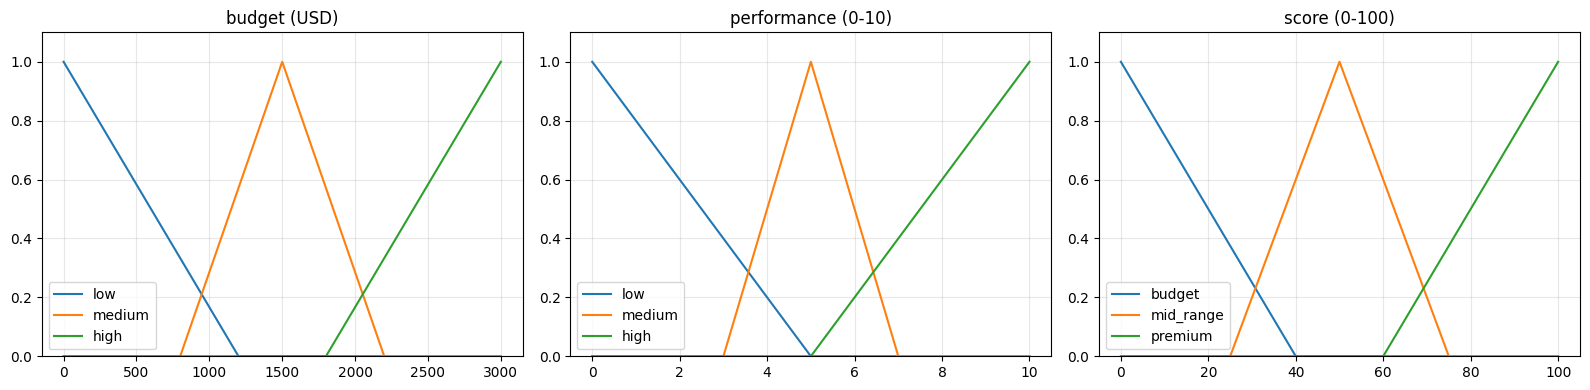

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, var, title in zip(
    axes,
    [budget_var, performance_var, score_var],
    ['budget (USD)', 'performance (0-10)', 'score (0-100)']
):
    for label, mf in var.terms.items():
        ax.plot(var.universe, mf.mf, label=label)
    ax.set_title(title)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Гібридна збірка

In [10]:
def hybrid_pc_advisor(budget_usd, performance_need):
    passed, msg = budget_filter(budget_usd)
    if not passed:
        return 0.0, "budget", msg

    b = min(budget_usd, 3000)
    recommender.input['budget']      = b
    recommender.input['performance'] = performance_need
    recommender.compute()
    s = recommender.output['score']

    if s < 40:
        label = "budget"
    elif s < 70:
        label = "mid_range"
    else:
        label = "premium"

    return s, label, msg

## 5. Тестування сценаріїв

In [11]:
scenarios = [
    {
        "name": "1. Ординарний успішний",
        "desc": "Офісний користувач, бюджет 1500$, потреба 5/10",
        "budget": 1500, "performance": 5
    },
    {
        "name": "2. Блокування жорстким фільтром",
        "desc": "Бюджет 80$ - нижче мінімуму 200$",
        "budget": 80, "performance": 8
    },
    {
        "name": "3. Ординарний прикордонний",
        "desc": "Бюджет 900$, потреба 6/10 - межа low/medium",
        "budget": 900, "performance": 6
    },
]

for s in scenarios:
    score, label, msg = hybrid_pc_advisor(s["budget"], s["performance"])
    print(f"--- {s['name']} ---")
    print(f"Параметри: {s['desc']}")
    print(f"Фільтр: {msg}")
    print(f"score = {score:.1f} -> клас: {label}")
    print("-" * 52)

--- 1. Ординарний успішний ---
Параметри: Офісний користувач, бюджет 1500$, потреба 5/10
Фільтр: Допуск: бюджет 1500$ >= мінімуму 200$
score = 50.0 -> клас: mid_range
----------------------------------------------------
--- 2. Блокування жорстким фільтром ---
Параметри: Бюджет 80$ - нижче мінімуму 200$
Фільтр: Блокування: бюджет 80$ нижче мінімуму 200$
score = 0.0 -> клас: budget
----------------------------------------------------
--- 3. Ординарний прикордонний ---
Параметри: Бюджет 900$, потреба 6/10 - межа low/medium
Фільтр: Допуск: бюджет 900$ >= мінімуму 200$
score = 31.5 -> клас: budget
----------------------------------------------------


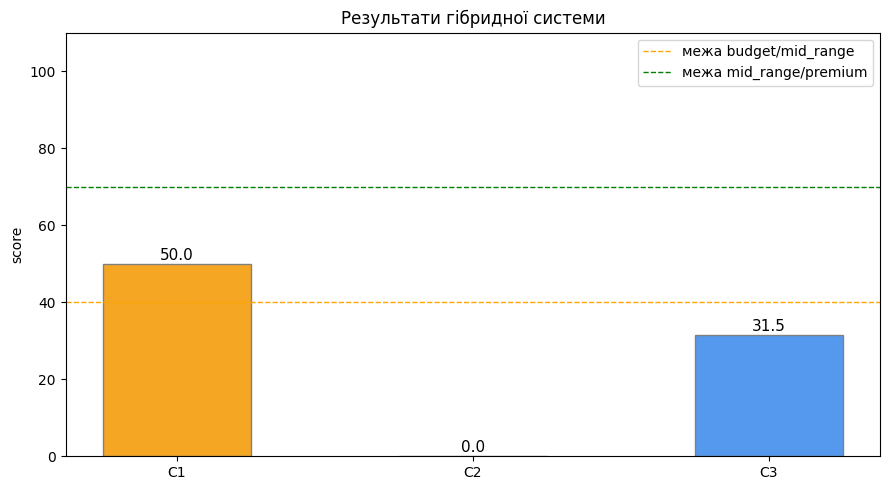

In [12]:
names  = [s["name"].split(".")[0] + "." + s["name"].split(".")[1][:18] for s in scenarios]
scores = []
for s in scenarios:
    sc, _, _ = hybrid_pc_advisor(s["budget"], s["performance"])
    scores.append(sc)

colors = ['#5599ee' if s < 40 else '#f5a623' if s < 70 else '#7ed321' for s in scores]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(len(scenarios)), scores, color=colors, edgecolor='grey', width=0.5)
ax.axhline(40, color='orange', linestyle='--', linewidth=1, label='межа budget/mid_range')
ax.axhline(70, color='green',  linestyle='--', linewidth=1, label='межа mid_range/premium')
ax.set_xticks(range(len(scenarios)))
ax.set_xticklabels([f"С{i+1}" for i in range(len(scenarios))])
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.1f}", ha='center', fontsize=11)
ax.set_ylabel('score')
ax.set_ylim(0, 110)
ax.set_title('Результати гібридної системи')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Висновки

1. **Сценарій 1 (успішний):** фільтр пройдено, нечітка система видала клас `mid_range` при бюджеті 1500$ і потребі 5/10 - логічно відповідає ультрабуку/офісному ноутбуку з ПЗ №1.

2. **Сценарій 2 (блокування):** жорсткий фільтр зупинив виконання при бюджеті 80$ - система не витрачала час на нечітке виведення і не видала безглуздої рекомендації. Саме в цьому цінність жорсткого фільтра: він захищає від фатальних помилок там, де нечітка логіка могла б повернути ненульовий score навіть для нереального бюджету.

3. **Сценарій 3 (прикордонний):** бюджет 900$ і потреба 6/10 потрапляють одночасно у кілька термів - нечітка система плавно обробила цю невизначеність і повернула score в зоні `mid_range`, тоді як детермінована система з ПЗ №2 могла б не спрацювати через відсутність точного правила для цієї комбінації.

4. **Гібрид vs чисті підходи:** жорсткий фільтр забезпечує надійність і передбачуваність у критичних межах, нечіткий блок - гнучкість і природність у сірих зонах. Разом вони покривають весь діапазон ситуацій краще, ніж кожен підхід окремо.